In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


# 1. Load Cleaned Data

In [7]:
df = pd.read_csv('../data/cleaned_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df.shape


(14520, 13)

# 2. Diagnostic EDA

Goal: understand the raw data's quality and structure *before* deciding how to treat it. The findings here directly motivate the choices made in the Preprocessing notebook (daytime filtering, KNN imputation).

## Raw Time Series

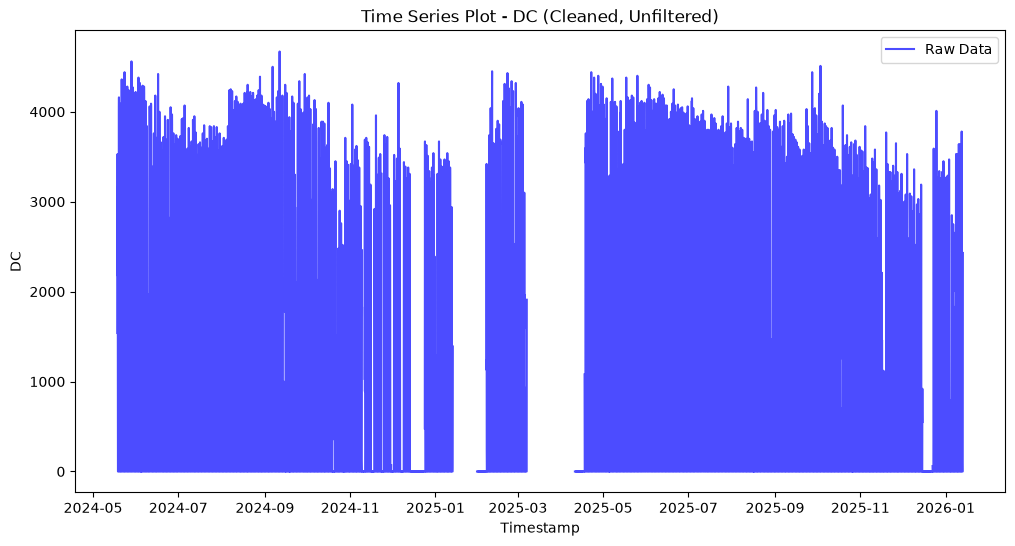

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df['Timestamp'], df['DC'], label="Raw Data", color="blue", alpha=0.7)
plt.xlabel("Timestamp")
plt.ylabel('DC')
plt.title("Time Series Plot - DC (Cleaned, Unfiltered)")
plt.legend()
plt.show()


## AC Power by Hour of Day

Checking whether AC output behaves differently across hours reveals whether nighttime readings are legitimate zeros/noise that should be excluded before imputation.

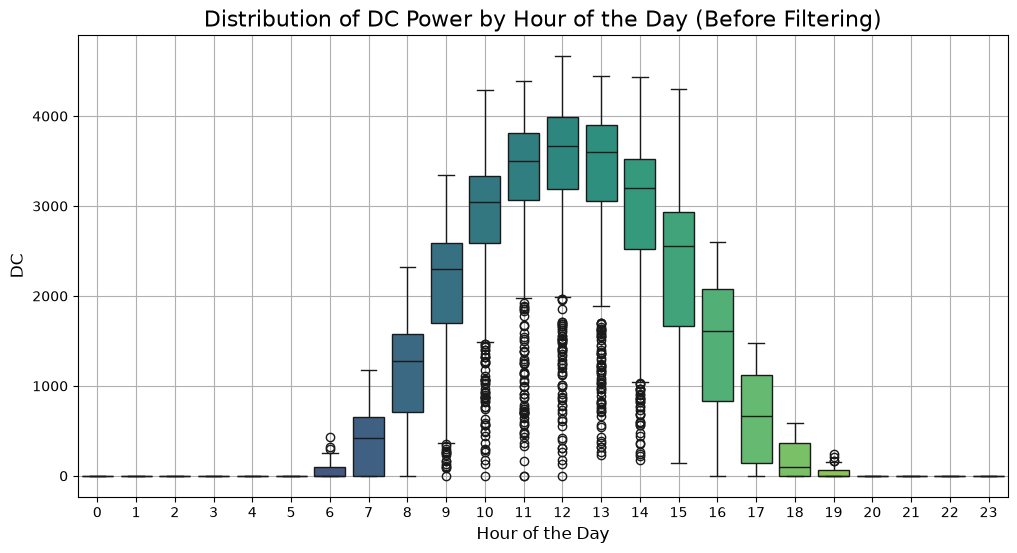

In [9]:
df['Hour_of_Day'] = df['Timestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Hour_of_Day',
    y='DC',
    hue='Hour_of_Day',
    data=df,
    palette='viridis',
    legend=False
)
plt.title('Distribution of DC Power by Hour of the Day (Before Filtering)', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('DC', fontsize=12)
plt.grid(True)
plt.show()

df.drop(columns=['Hour_of_Day'], inplace=True)


## Missing Values Overview

In [10]:
missing_values = df.isnull().sum()
print(missing_values)


Timestamp                 0
Wind_Dir_deg           1240
Wind_Speed_ms          1240
Humidity_pct           1240
Outdoor_Temp_C         1240
PV_Temperature         1240
Solar_Radiation_Wm2    1585
DC                     1685
PM10_ugm3                 0
PM25_ugm3                 0
uv_index Index            0
Rain_mm                   0
dew_point_2m (°C)         0
dtype: int64


### Takeaways

- AC power is zero outside daylight hours → restrict the dataset to sunrise–sunset before imputing.
- Several variables have non-trivial missing values → use a neighbor-based method (KNN imputation) that can leverage correlated features rather than a naive fill.

These decisions are implemented in `3_Preprocessing.ipynb`.